In [1]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas ✓")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Librerías cargadas ✓


In [2]:
# Descargar datos de Rambus (Empresa a analizar)
rmbs = yf.Ticker("RMBS")

# Información general de la empresa
info = rmbs.info
print(f"Empresa:        {info.get('longName')}")
print(f"Sector:         {info.get('sector')}")
print(f"Industria:      {info.get('industry')}")
print(f"Empleados:      {info.get('fullTimeEmployees'):,}")
print(f"\nPrecio actual:  ${info.get('currentPrice')}")
print(f"52w Máximo:     ${info.get('fiftyTwoWeekHigh')}")
print(f"52w Mínimo:     ${info.get('fiftyTwoWeekLow')}")
print(f"\nMarket Cap:     ${info.get('marketCap')/1e9:.2f}B")
print(f"P/E Ratio:      {info.get('trailingPE'):.2f}x")
print(f"P/B Ratio:      {info.get('priceToBook'):.2f}x")
print(f"EV/EBITDA:      {info.get('enterpriseToEbitda'):.2f}x")

Empresa:        Rambus Inc.
Sector:         Technology
Industria:      Semiconductors
Empleados:      791

Precio actual:  $96.96
52w Máximo:     $174.1
52w Mínimo:     $77.89

Market Cap:     $10.52B
P/E Ratio:      44.48x
P/B Ratio:      7.17x
EV/EBITDA:      30.69x


In [3]:
# Estados financieros
income_stmt = rmbs.financials          # Estado de resultados anual
balance     = rmbs.balance_sheet       # Balance general anual
cashflow    = rmbs.cashflow            # Flujo de efectivo anual

print("=== ESTADO DE RESULTADOS ===")
print(income_stmt.loc[['Total Revenue', 'Gross Profit', 'EBITDA', 'Net Income']].to_string())

=== ESTADO DE RESULTADOS ===
                2025-12-31   2024-12-31   2023-12-31   2022-12-31  2021-12-31
Total Revenue  707630000.0  556624000.0  461117000.0  454793000.0         NaN
Gross Profit   563215000.0  446517000.0  357695000.0  347214000.0         NaN
EBITDA         325318000.0  244149000.0  237078000.0   41176000.0         NaN
Net Income     230455000.0  179821000.0  333904000.0  -14310000.0         NaN


In [6]:
# Análisis de márgenes
revenue      = income_stmt.loc['Total Revenue']
gross_profit = income_stmt.loc['Gross Profit']
ebitda       = income_stmt.loc['EBITDA']
net_income   = income_stmt.loc['Net Income']

margenes = pd.DataFrame({
    'Revenue ($M)':       (revenue / 1e6).round(1),
    'Gross Margin %':     (gross_profit / revenue * 100).round(1),
    'EBITDA Margin %':    (ebitda / revenue * 100).round(1),
    'Net Margin %':       (net_income / revenue * 100).round(1),
})

# Ordenar años de menor a mayor
margenes = margenes.iloc[::-1].dropna()

print("=== EVOLUCIÓN DE MÁRGENES RAMBUS ===")
print(margenes.to_string())

=== EVOLUCIÓN DE MÁRGENES RAMBUS ===
            Revenue ($M)  Gross Margin %  EBITDA Margin %  Net Margin %
2022-12-31         454.8            76.3              9.1          -3.1
2023-12-31         461.1            77.6             51.4          72.4
2024-12-31         556.6            80.2             43.9          32.3
2025-12-31         707.6            79.6             46.0          32.6


In [7]:
# Flujo de efectivo y balance
print("=== FLUJO DE EFECTIVO ===")
cashflow_items = cashflow.loc[[
    'Operating Cash Flow',
    'Capital Expenditure',
    'Free Cash Flow'
]]
cashflow_items = cashflow_items.iloc[:, ::-1].dropna(axis=1)
print((cashflow_items / 1e6).round(1).to_string())

print("\n=== BALANCE GENERAL ===")
balance_items = balance.loc[[
    'Total Assets',
    'Total Liabilities Net Minority Interest',
    'Cash And Cash Equivalents',
    'Stockholders Equity'
]]
balance_items = balance_items.iloc[:, ::-1].dropna(axis=1)
print((balance_items / 1e6).round(1).to_string())

=== FLUJO DE EFECTIVO ===
                     2022-12-31  2023-12-31  2024-12-31  2025-12-31
Operating Cash Flow       230.4       195.8       230.6       360.0
Capital Expenditure       -20.5       -23.2       -30.7       -26.8
Free Cash Flow            209.9       172.5       199.9       333.2

=== BALANCE GENERAL ===
                                         2022-12-31  2023-12-31  2024-12-31  2025-12-31
Total Assets                                 1012.6      1258.2      1343.1      1529.5
Total Liabilities Net Minority Interest       233.3       220.1       222.4       165.1
Cash And Cash Equivalents                     125.3        94.8        99.8       182.8
Stockholders Equity                           779.3      1038.1      1120.7      1364.4


In [8]:
# Ratios de valuación
precio        = info.get('currentPrice')
shares        = info.get('sharesOutstanding')
market_cap    = precio * shares
ebitda_2025   = income_stmt.loc['EBITDA'].iloc[0]
fcf_2025      = cashflow.loc['Free Cash Flow'].iloc[0]
net_income_25 = income_stmt.loc['Net Income'].iloc[0]
cash          = balance.loc['Cash And Cash Equivalents'].iloc[0]
debt          = balance.loc['Total Debt'].iloc[0] if 'Total Debt' in balance.index else 0

ev = market_cap + debt - cash

print(f"=== VALUACIÓN RAMBUS A ${precio} ===")
print(f"\nMarket Cap:      ${market_cap/1e9:.2f}B")
print(f"Deuda neta:      ${(debt-cash)/1e6:.0f}M")
print(f"Enterprise Value:${ev/1e9:.2f}B")

print(f"\n--- Ratios ---")
print(f"P/E  (Price/Earnings):  {precio / (net_income_25/shares):.1f}x")
print(f"P/FCF (Price/FCF):      {market_cap / fcf_2025:.1f}x")
print(f"EV/EBITDA:              {ev / ebitda_2025:.1f}x")
print(f"FCF Yield:              {fcf_2025/market_cap*100:.1f}%")

print(f"\n--- Precio implícito por múltiplo ---")
pe_sector     = 25
evebitda_sect = 20
print(f"Si P/E sector (25x):       ${(net_income_25/shares) * pe_sector:.2f}")
print(f"Si EV/EBITDA sector (20x): ${(evebitda_sect * ebitda_2025 - debt + cash)/shares:.2f}")

=== VALUACIÓN RAMBUS A $96.96 ===

Market Cap:      $10.52B
Deuda neta:      $-158M
Enterprise Value:$10.36B

--- Ratios ---
P/E  (Price/Earnings):  45.6x
P/FCF (Price/FCF):      31.6x
EV/EBITDA:              31.8x
FCF Yield:              3.2%

--- Precio implícito por múltiplo ---
Si P/E sector (25x):       $53.12
Si EV/EBITDA sector (20x): $61.44


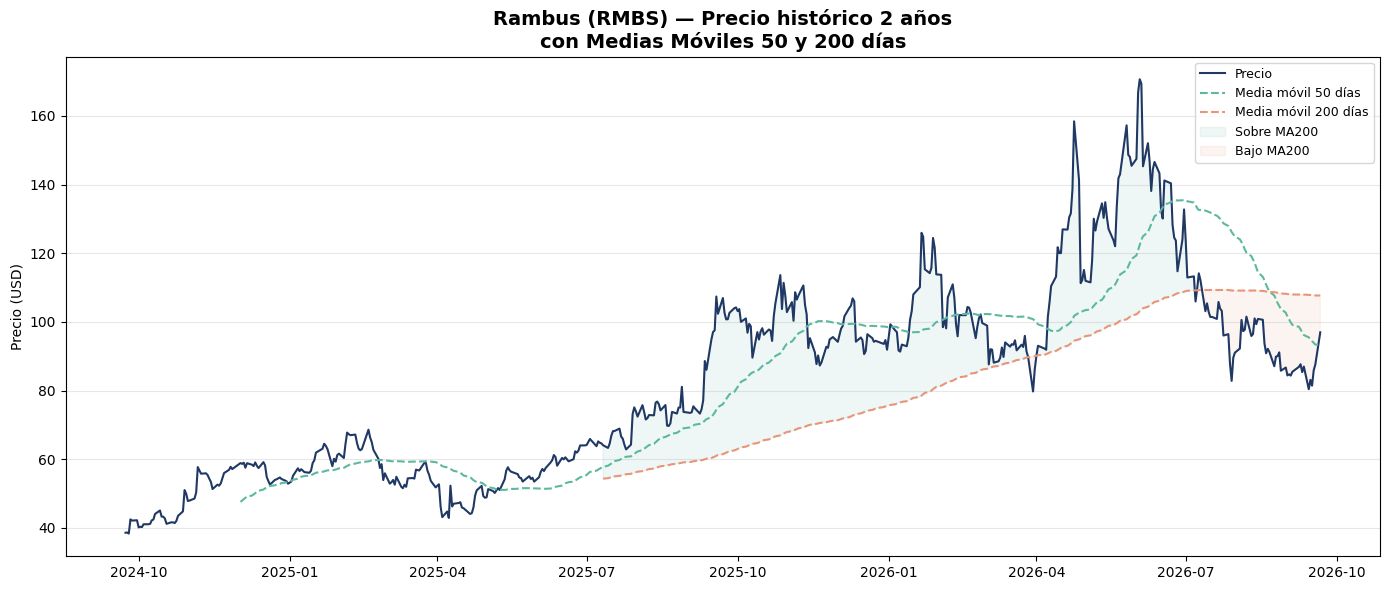

In [9]:
# Precio histórico y medias móviles
hist = rmbs.history(period="2y")

hist['MA50']  = hist['Close'].rolling(50).mean()
hist['MA200'] = hist['Close'].rolling(200).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hist.index, hist['Close'], color='#1F3864', linewidth=1.5, label='Precio')
ax.plot(hist.index, hist['MA50'],  color='#5DB8A0', linewidth=1.5, linestyle='--', label='Media móvil 50 días')
ax.plot(hist.index, hist['MA200'], color='#E8957A', linewidth=1.5, linestyle='--', label='Media móvil 200 días')

ax.fill_between(hist.index, hist['Close'], hist['MA200'],
                where=hist['Close'] > hist['MA200'],
                alpha=0.1, color='#5DB8A0', label='Sobre MA200')
ax.fill_between(hist.index, hist['Close'], hist['MA200'],
                where=hist['Close'] < hist['MA200'],
                alpha=0.1, color='#E8957A', label='Bajo MA200')

ax.set_title('Rambus (RMBS) — Precio histórico 2 años\ncon Medias Móviles 50 y 200 días',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.yaxis.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

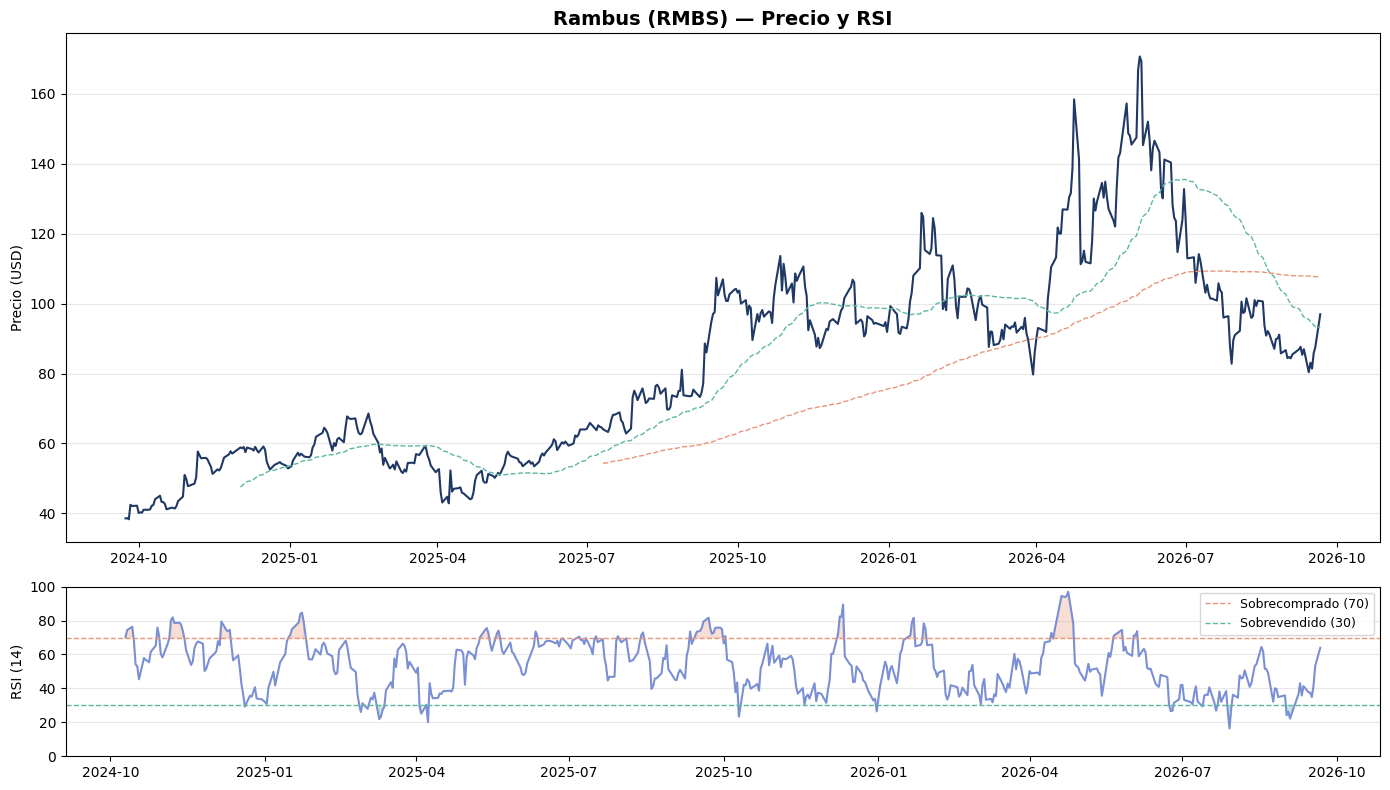

In [10]:
# RSI (Relative Strength Index)
delta  = hist['Close'].diff()
gain   = delta.where(delta > 0, 0).rolling(14).mean()
loss   = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs     = gain / loss
hist['RSI'] = 100 - (100 / (1 + rs))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Precio
ax1.plot(hist.index, hist['Close'], color='#1F3864', linewidth=1.5)
ax1.plot(hist.index, hist['MA50'],  color='#5DB8A0', linewidth=1, linestyle='--')
ax1.plot(hist.index, hist['MA200'], color='#E8957A', linewidth=1, linestyle='--')
ax1.set_title('Rambus (RMBS) — Precio y RSI', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precio (USD)')
ax1.yaxis.grid(True, alpha=0.3)

# RSI
ax2.plot(hist.index, hist['RSI'], color='#7A8FD4', linewidth=1.5)
ax2.axhline(70, color='#E8957A', linewidth=1, linestyle='--', label='Sobrecomprado (70)')
ax2.axhline(30, color='#5DB8A0', linewidth=1, linestyle='--', label='Sobrevendido (30)')
ax2.fill_between(hist.index, hist['RSI'], 30,
                 where=hist['RSI'] < 30, color='#5DB8A0', alpha=0.3)
ax2.fill_between(hist.index, hist['RSI'], 70,
                 where=hist['RSI'] > 70, color='#E8957A', alpha=0.3)
ax2.set_ylabel('RSI (14)')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9)
ax2.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Resumen de inversión
precio_actual  = info.get('currentPrice')
target_analistas = 139.25
min_52 = info.get('fiftyTwoWeekLow')
max_52 = info.get('fiftyTwoWeekHigh')

upside_analistas = (target_analistas - precio_actual) / precio_actual * 100
downside_soporte = (min_52 - precio_actual) / precio_actual * 100

print("=" * 55)
print("RESUMEN DE INVERSIÓN — RAMBUS (RMBS)")
print("=" * 55)

print(f"\n📊 PRECIO ACTUAL:        ${precio_actual}")
print(f"   Mínimo 52 semanas:   ${min_52}  ({downside_soporte:.1f}%)")
print(f"   Máximo 52 semanas:   ${max_52}")
print(f"   Target analistas:    ${target_analistas} (+{upside_analistas:.1f}% upside)")

print(f"\n✅ FORTALEZAS")
print(f"   • Gross Margin ~80% — modelo de IP escalable")
print(f"   • FCF creció 55% en 2025 — $333M generados")
print(f"   • Balance sin deuda neta — $158M caja neta")
print(f"   • Revenue creciendo 27% anual promedio")

print(f"\n⚠️  RIESGOS")
print(f"   • Valuación premium: EV/EBITDA 31.8x vs sector 20x")
print(f"   • Dependencia de lanzamientos Intel/AMD")
print(f"   • RSI acercándose a sobrecompra")
print(f"   • Posible Death Cross en medias móviles")

print(f"\n💡 ESCENARIOS DE PRECIO")
print(f"   Conservador (EV/EBITDA 20x): $61")
print(f"   Base (EV/EBITDA 25x):        $78")
print(f"   Optimista (target analistas): $139")

print(f"\n📋 CONCLUSIÓN")
print(f"   Empresa excelente con fundamentales sólidos.")
print(f"   Valuación premium que requiere creer en")
print(f"   continuidad del ciclo AI + DDR5/HBM4.")
print(f"   Precio de entrada atractivo: $77-$85")
print(f"   (cerca del mínimo 52 semanas y soporte técnico)")
print("=" * 55)

RESUMEN DE INVERSIÓN — RAMBUS (RMBS)

📊 PRECIO ACTUAL:        $96.96
   Mínimo 52 semanas:   $77.89  (-19.7%)
   Máximo 52 semanas:   $174.1
   Target analistas:    $139.25 (+43.6% upside)

✅ FORTALEZAS
   • Gross Margin ~80% — modelo de IP escalable
   • FCF creció 55% en 2025 — $333M generados
   • Balance sin deuda neta — $158M caja neta
   • Revenue creciendo 27% anual promedio

⚠️  RIESGOS
   • Valuación premium: EV/EBITDA 31.8x vs sector 20x
   • Dependencia de lanzamientos Intel/AMD
   • RSI acercándose a sobrecompra
   • Posible Death Cross en medias móviles

💡 ESCENARIOS DE PRECIO
   Conservador (EV/EBITDA 20x): $61
   Base (EV/EBITDA 25x):        $78
   Optimista (target analistas): $139

📋 CONCLUSIÓN
   Empresa excelente con fundamentales sólidos.
   Valuación premium que requiere creer en
   continuidad del ciclo AI + DDR5/HBM4.
   Precio de entrada atractivo: $77-$85
   (cerca del mínimo 52 semanas y soporte técnico)


## Análisis de Inversión — Rambus (RMBS)

### Fundamentales
- Gross Margin ~80%, FCF $333M (+55% en 2025), sin deuda neta
- Revenue creciendo 27% anual promedio
- Modelo de IP escalable con exposición directa a AI/DDR5/HBM4

### Valuación
- EV/EBITDA 31.8x vs sector 20x — premium significativo
- Precio justo conservador: $61 | Base: $78 | Optimista: $139

### Técnico
- Precio recuperándose desde mínimos pero RSI cerca de sobrecompra
- Posible Death Cross MA50/MA200 — señal de cautela

### Conclusión
Empresa de alta calidad pero valuación exigente.
Zona de entrada atractiva: $77–$85.
Catalizador principal: lanzamientos HBM4 y adopción AI en data centers.